# Train CNN with with Colab (GPU)

## Mounting to google colab, loading from google drive, paths...

In [1]:
from pathlib import Path
import sys
import os
import numpy as np


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive") # mount the drive
    DATA_PATH = Path("/content/drive/MyDrive") # the root of the drive
    DATA_ROOT = DATA_PATH / "cbc_pe_data" # the root of the data
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))
    DATA_ROOT = PROJECT_ROOT / "data"


DATA_RAW = DATA_ROOT / "raw" # the root of the raw data
DATA_PROCESSED = DATA_ROOT / "processed" # the root of the processed data
MODELS_DIR = DATA_ROOT / "models" # the root of the models
RESULTS_DIR = DATA_ROOT / "results" # the root of the results
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" # the root of the checkpoints

for path in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_RAW:", DATA_RAW)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CHECKPOINTS_DIR:", CHECKPOINTS_DIR)
# 


#Clone the repository if it doesn't exist
if IN_COLAB:
    REPO_ROOT = Path("/content/Gravitational-Waves-Lab")
    PROJECT_ROOT = REPO_ROOT / "cbc_pe"

    if not REPO_ROOT.exists():
        !git clone https://github.com/victorsh13/Gravitational-Waves-Lab.git /content/Gravitational-Waves-Lab

    print("REPO_ROOT exists:", REPO_ROOT.exists())
    print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

    #Pull the latest version of the repository
    %cd /content/Gravitational-Waves-Lab
    !git pull
    !git status

    #Go to the project root
    %cd /content/Gravitational-Waves-Lab/cbc_pe
else:
    %cd /home/victor/gw/cbc_pe
    


# Add the project root to the python path
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("sys.path[:3]:", sys.path[:3])

Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/cbc_pe_data
DATA_RAW: /content/drive/MyDrive/cbc_pe_data/raw
MODELS_DIR: /content/drive/MyDrive/cbc_pe_data/models
RESULTS_DIR: /content/drive/MyDrive/cbc_pe_data/results
CHECKPOINTS_DIR: /content/drive/MyDrive/cbc_pe_data/models/checkpoints
Cloning into '/content/Gravitational-Waves-Lab'...
remote: Enumerating objects: 407, done.
remote: Counting objects: 100% (304/304), done.
remote: Compressing objects: 100% (209/209), done.
remote: Total 407 (delta 174), reused 212 (delta 91), pack-reused 103 (from 1)
Receiving objects: 100% (407/407), 68.66 MiB | 32.98 MiB/s, done.
Resolving deltas: 100% (201/201), done.
REPO_ROOT exists: True
PROJECT_ROOT exists: True
/content/Gravitational-Waves-Lab
Already up to date.
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
/content/Gravitational-Waves-Lab/cbc_pe
cwd: /content/Gravitational-Waves-Lab/cbc_pe
sys.path[:3]: ['/content/Gravitation

## Load the data

In [2]:
from pathlib import Path
import numpy as np

from src.io import load_dataset_npz

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n15000_merged"

dataset_path = DATA_PROCESSED / f"{dataset_id}.npz"

split_path = DATA_PROCESSED / (
    f"{dataset_id}_splits_train12000_val3000_seed123.npz"
)

label_stats_path = DATA_PROCESSED / (
    f"{dataset_id}_label_stats_train_only_seed123.npz"
)

assert dataset_path.exists(), dataset_path
assert split_path.exists(), split_path

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
metadata = batch.metadata
# SNR final de red, uno por sample
network_snrs = np.array([
    m["snr"]["final_network_snr"]
    for m in metadata
], dtype=np.float32)

# SNR final por detector, uno por muestra y detector
detector_names = metadata[0]["detectors"]

detector_snrs = {
    det: np.array([
        m["snr"]["final_detector_snrs"][det]
        for m in metadata
    ], dtype=np.float32)
    for det in detector_names
}

print("X:", X.shape)
print("y:", y.shape)
print("network_snrs:", network_snrs.shape)
print("detectors:", detector_names)

print("Network SNR min/max:", network_snrs.min(), network_snrs.max())
for det in detector_names:
    print(det, detector_snrs[det].min(), detector_snrs[det].max())

splits = np.load(split_path)

train_idx = splits["train_idx"]
val_idx = splits["val_idx"]

all_idx = np.concatenate([train_idx, val_idx])

X_train, y_train_phys = X[train_idx], y[train_idx]
X_val, y_val_phys = X[val_idx], y[val_idx]

print("X_train:", X_train.shape, "y_train_phys:", y_train_phys.shape)
print("X_val:", X_val.shape, "y_val_phys:", y_val_phys.shape)


X: (15000, 3, 16384)
y: (15000, 3)
network_snrs: (15000,)
detectors: ['H1', 'L1', 'V1']
Network SNR min/max: 10.000044 24.999886
H1 0.32628405 23.930035
L1 0.07767382 23.038021
V1 0.04745898 24.526678
X_train: (12000, 3, 16384) y_train_phys: (12000, 3)
X_val: (3000, 3, 16384) y_val_phys: (3000, 3)


## Label Standardization

Standarize the labels using the mean and standard deviation of the training set and save it in DATA_PROCESSED.
This will be needed to revert the normalization and interpret the predictions as physical quantities.

In [3]:
stats = np.load(label_stats_path)

y_mean = stats["y_mean"]
y_std = stats["y_std"]

label_names = stats["label_names"].tolist()

eps = 1e-8
y_std_safe = y_std + eps

y_train_std = (y_train_phys - y_mean) / y_std_safe
y_val_std = (y_val_phys - y_mean) / y_std_safe

print("label_names:", label_names)
print("y_mean:", y_mean)
print("y_std:", y_std)

print("train std mean:", y_train_std.mean(axis=0))
print("train std std:", y_train_std.std(axis=0))
print("val std mean:", y_val_std.mean(axis=0))
print("val std std:", y_val_std.std(axis=0))

label_names: ['chirp_mass', 'total_mass', 'chi_eff']
y_mean: [ 3.7359344e+01  9.4854393e+01 -2.5125335e-03]
y_std: [16.60169    34.843903    0.44303825]
train std mean: [-2.6911498e-06  6.7249734e-06  3.1635786e-08]
train std std: [1.000001  1.0000008 1.0000006]
val std mean: [ 0.04017385  0.04128974 -0.02555423]
val std std: [1.0010064 0.9995316 0.9844474]


## Datasets & DataLoaders

Create PyTorch datasets and dataloaders.

In [4]:
from torch.utils.data import DataLoader
from src.models.dataset import ArrayRegressionDataset

batch_size = 64  # prueba 64; si da OOM, baja a 32

X_train_input = X_train.astype(np.float32)
X_val_input = X_val.astype(np.float32)

y_train_std = y_train_std.astype(np.float32)
y_val_std = y_val_std.astype(np.float32)

train_dataset = ArrayRegressionDataset(X_train_input, y_train_std)
val_dataset = ArrayRegressionDataset(X_val_input, y_val_std)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

Para cargar desde hdf5 file (abriendo el archivo dentro del worker, no antes), de forma lazy

In [ ]:
from src.models.dataset import HDF5RegressionDataset

train_dataset = HDF5RegressionDataset(
    h5_path=h5_path,
    indices=train_idx,
    y_mean=y_mean,
    y_std=y_std,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

## Train the CNN and save the model

Function to train the CNN

### Small test

In [11]:
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn

from src.models.network import SimpleCNN
from src.models.train import train_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

small_dataset = ArrayRegressionDataset(X_train_norm, y_train_std)

small_loader = DataLoader(
    Subset(small_dataset, list(range(64))),
    batch_size=64,
    shuffle=True,
)

model = SimpleCNN(
    n_detectors=3,
    n_outputs=3,
    embedding_dim=32,
    dropout_conv=0.0,
    dropout_dense=0.0,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
loss_fn = nn.MSELoss()

for epoch in range(200):
    train_loss = train_one_epoch(
        model=model,
        loader=small_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
    )

    if (epoch + 1) % 20 == 0:
        print(epoch + 1, train_loss)

In [12]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())

In [13]:
xb, yb = next(iter(train_loader))

print("xb mean:", xb.mean().item())
print("xb std:", xb.std().item())
print("xb min/max:", xb.min().item(), xb.max().item())
print("yb mean:", yb.mean(dim=0))
print("yb std:", yb.std(dim=0))

### Full CNN

In [5]:
from src.models.train import train_model
from src.models.network import SimpleCNN, SimpleCNN_v2, SimpleCNN_Pool
from src.models.utils import set_seed
import torch 

seed = 123
set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_config = {
    "architecture": "SimpleCNN_GN_v1",
    "dataset_id": dataset_id,
    "n_detectors": 3,
    "n_outputs": 3,
    "embedding_dim": 64,
    "dropout_conv": 0.05,
    "dropout_dense": 0.1,
    "normalization": "GroupNorm",
    "activation_conv": "LeakyReLU(0.01)",
    "activation_dense": "LeakyReLU(0.1)",
    "loss": "MSELoss",
    "train_size": len(train_idx),
    "val_size": len(val_idx),
    "split_seed": 123,
    "pool_size": 4,
}


model = SimpleCNN_Pool(
    n_detectors=model_config["n_detectors"],
    n_outputs=model_config["n_outputs"],
    embedding_dim=model_config["embedding_dim"],
    dropout_conv=model_config["dropout_conv"],
    dropout_dense=model_config["dropout_dense"],
    pool_size=model_config["pool_size"],
).to(device)


best_checkpoint, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    y_mean=y_mean,
    y_std=y_std,
    model_config=model_config,
    seed=seed,
    batch_size=batch_size,
    max_epochs=200,
    patience=40,
    learning_rate=3e-4,
    weight_decay=3e-4,
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

print("Best epoch:", best_checkpoint["epoch"])
print("Best val loss:", best_checkpoint["best_val_loss"])

Using device: cuda
Epoch 001 | train_loss = 1.002746 | val_loss = 0.983707 | best_val = 0.983707
Epoch 002 | train_loss = 0.816699 | val_loss = 0.658864 | best_val = 0.658864
Epoch 003 | train_loss = 0.635702 | val_loss = 0.570414 | best_val = 0.570414
Epoch 004 | train_loss = 0.593381 | val_loss = 0.559399 | best_val = 0.559399
Epoch 005 | train_loss = 0.584218 | val_loss = 0.560259 | best_val = 0.559399
Epoch 006 | train_loss = 0.576425 | val_loss = 0.561920 | best_val = 0.559399
Epoch 007 | train_loss = 0.565565 | val_loss = 0.543216 | best_val = 0.543216
Epoch 008 | train_loss = 0.560096 | val_loss = 0.546111 | best_val = 0.543216
Epoch 009 | train_loss = 0.552484 | val_loss = 0.522204 | best_val = 0.522204
Epoch 010 | train_loss = 0.541431 | val_loss = 0.507170 | best_val = 0.507170
Epoch 011 | train_loss = 0.541587 | val_loss = 0.517101 | best_val = 0.507170
Epoch 012 | train_loss = 0.530823 | val_loss = 0.506255 | best_val = 0.506255
Epoch 013 | train_loss = 0.526323 | val_loss 

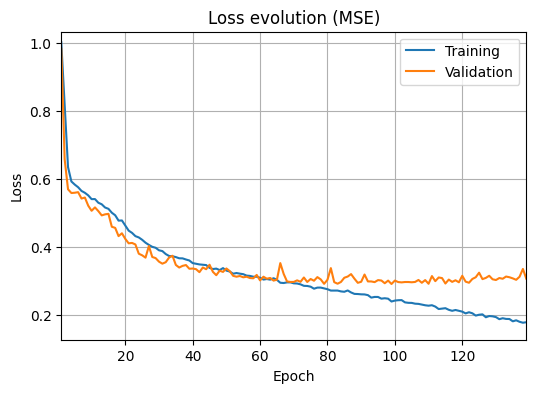

In [6]:
history = best_checkpoint["history"]

train_loss = history["train_loss"]
val_loss = history["val_loss"]

import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 1, figsize=(6, 4))

last_epoch = len(train_loss)
plt.plot(np.arange(1, last_epoch+1), train_loss, label="Training")
plt.plot(np.arange(1, last_epoch+1), val_loss, label="Validation")
ax.set_xlim(1, last_epoch)
ax.set_ylim(min(train_loss)-0.05, max(val_loss)+0.05)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss evolution (MSE)")
ax.legend()
ax.grid()


### Save & Load the best checkpoint

In [8]:
#checkpoint_file_name = "bbh_processed_4s_seobnrv4opt_snr10-25_n4500_emb64_checkpoint.pt"
# checkpoint_file_name = (
#     f"{dataset_id}"
#     f"_SimpleCNN"
#     f"_MSELoss"
#     f"_emb{model_config['embedding_dim']}"
#     f"_seed{seed}"
#     f"_checkpoint.pt"
# )

# File with pool
checkpoint_file_name = (
    f"{dataset_id}"
    f"_SimpleCNNPool"
    f"_pool{model_config['pool_size']}"
    f"_MSELoss"
    f"_emb{model_config['embedding_dim']}"
    f"_seed{seed}"
    f"_checkpoint.pt"
)


torch.save(
    best_checkpoint,
    CHECKPOINTS_DIR / checkpoint_file_name,
)


print("Saved checkpoint:", CHECKPOINTS_DIR / checkpoint_file_name)

# _______________________ LOAD ______________________

checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,)

Saved checkpoint: /content/drive/MyDrive/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n15000_merged_SimpleCNNPool_pool4_MSELoss_emb64_seed123_checkpoint.pt


In [3]:
train_loader_eval = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

Check and save values for val(test)

In [ ]:
from src.models.evaluate import extract_predictions_and_embeddings

model.eval()

pred_train, emb_train, y_train_eval = extract_predictions_and_embeddings(
    model,
    train_loader_eval,
    device,
)

pred_val, emb_val, y_val_eval = extract_predictions_and_embeddings(
    model,
    val_loader,
    device,
)

Add it to the json file

## Extraer predicciones y embeddings (After training)

Get the predictions, embeddings and labels for the calibration and test sets.

And the we save all the results (predictions, embeddings, labels) to use later in Mondrian.

In [ ]:
pred_file = checkpoint_file_name.replace(".pt", "_train_val_predictions_embeddings.npz")

np.savez_compressed(
    RESULTS_DIR / pred_file,
    pred_train=pred_train,
    emb_train=emb_train,
    y_train=y_train_eval,
    pred_val=pred_val,
    emb_val=emb_val,
    y_val=y_val_eval,
    y_mean=y_mean,
    y_std=y_std,
    train_idx=train_idx,
    val_idx=val_idx,
    label_names=np.array(label_names),
    checkpoint_file=checkpoint_file_name,
)

print("Predictions/embeddings saved to:", RESULTS_DIR / pred_file)

### Testing the GPU

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("Total VRAM [GB]:", props.total_memory / 1024**3)

In [ ]:

print("Allocated [GB]:", torch.cuda.memory_allocated() / 1024**3)
print("Reserved [GB]:", torch.cuda.memory_reserved() / 1024**3)
print("Peak allocated [GB]:", torch.cuda.max_memory_allocated() / 1024**3)
print("Peak reserved [GB]:", torch.cuda.max_memory_reserved() / 1024**3)

In [ ]:
def test_batch_size(model, batch_size, n_detectors=3, signal_length=16384, device="cuda"):
    try:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        model.train()

        X = torch.randn(batch_size, n_detectors, signal_length, device=device)
        y = torch.randn(batch_size, 3, device=device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        loss_fn = torch.nn.MSELoss()

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        peak = torch.cuda.max_memory_allocated() / 1024**3
        print(f"batch_size={batch_size} OK | peak VRAM = {peak:.2f} GB")

        del X, y, pred, loss
        torch.cuda.empty_cache()

        return True

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"batch_size={batch_size} OOM")
            torch.cuda.empty_cache()
            return False
        else:
            raise e

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for bs in [32, 64, 96, 128, 192]:
    if device == "cuda":
        ok = test_batch_size(model, bs, device=device)
        if not ok:
            break